In [1]:
import pandas as pd
import numpy as np

data_dir = "data/raw"
customers = pd.read_csv(data_dir + "/customers.csv")
order_items = pd.read_csv(data_dir + "/order_items.csv")
orders = pd.read_csv(data_dir + "/orders.csv")
products = pd.read_csv(data_dir + "/products.csv")

print(customers.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB
None


메타플롭립

In [2]:

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

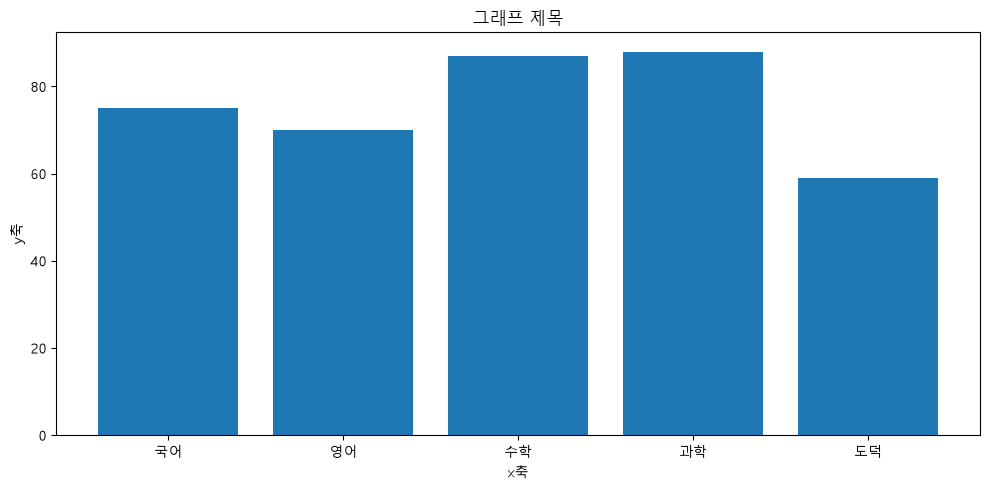

In [3]:
import matplotlib.pyplot as plt

x_data = ["국어", "영어", "수학", "과학", "도덕"]
y_data = [75, 70, 87, 88, 59]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [4]:
from matplotlib import font_manager
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "Apple Gothic", "Apple SD Gothic Neo", 
                   "Noto sans CJK KR", "NanumGothic", "Gungsuh"]


In [5]:
korean_font = next(
    (font for font in font_candidates if font in installed_fonts),None
    )
korean_font

'Malgun Gothic'

In [6]:
import matplotlib.pyplot as plt

korean_font = next(
    (name for name in font_candidates if name in installed_fonts),None
)

print("선택된 한글 폰트 : ",  korean_font)

if korean_font: 
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False


선택된 한글 폰트 :  Malgun Gothic


In [7]:
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="raise")
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 17.0 KB


In [8]:
df_visualization = pd.read_csv("data/processed/visualization.csv")
df_customers_clean = pd.read_csv("data/processed/customers_clean.csv")
df_orders_clean = pd.read_csv("data/processed/orders_clean.csv")
df_products_clean = pd.read_csv("data/processed/products_clean.csv")
df_order_items_clean = pd.read_csv("data/processed/order_items_clean.csv")

df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [9]:
df_visualization = df_visualization.dropna()
df_visualization.isna().sum().sum()

np.int64(0)

In [10]:
category_sales = df_visualization.groupby("category", dropna=False, as_index=False).agg(
    total_amount=("line_total", sum),
    total_quantity=("quantity", sum)
).sort_values("total_amount", ascending=False)

category_sales

,category,total_amount,total_quantity
9,패션,63322000.0,532.0
6,식품,45972000.0,384.0
8,전자기기,34218000.0,280.0
0,도서,27876000.0,272.0
2,뷰티,26467000.0,268.0
5,스포츠,20468000.0,253.0
4,생활용품,13835000.0,204.0
3,생활 용품,3224000.0,26.0
1,뷰 티,1026000.0,19.0
7,전자 기기,252000.0,12.0


In [11]:
category_sales.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 9 to 7
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        10 non-null     str    
 1   total_amount    10 non-null     float64
 2   total_quantity  10 non-null     float64
dtypes: float64(2), str(1)
memory usage: 412.0 bytes


막대그래프

(0.0, 66488100.0)

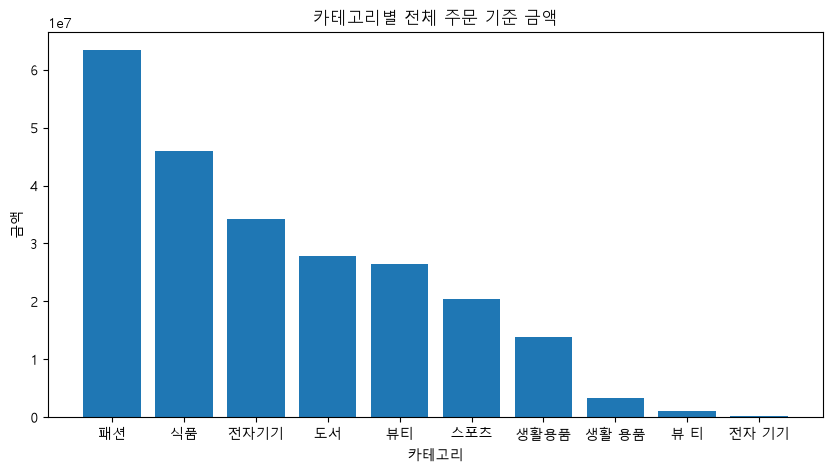

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)

ax.set_title("카테고리별 전체 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)

In [13]:
df_visualization.columns

Index(['order_item_id', 'order_id', 'customer_id', 'product_id', 'order_date',
       'order_month', 'order_dayofweek', 'payment_method', 'order_status',
       'gender', 'age', 'city', 'signup_date', 'product_name', 'category',
       'price', 'quantity', 'unit_price', 'line_total', 'order_match',
       'product_match', 'customer_match', 'merge_valid'],
      dtype='str')

In [14]:
monthly_sales = df_visualization.groupby(df_visualization["order_month"], as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique")
).sort_index()

monthly_sales

,order_month,total_amount,order_count
0,2025-07,13389000.0,18
1,2025-08,31736000.0,24
2,2025-09,12278000.0,12
3,2025-10,16352000.0,22
4,2025-11,12738000.0,22
5,2025-12,15684000.0,23
6,2026-01,18132000.0,25
7,2026-02,13582000.0,18
8,2026-03,13701000.0,22
9,2026-04,19700000.0,24


선그래프

Text(0, 0.5, '금액')

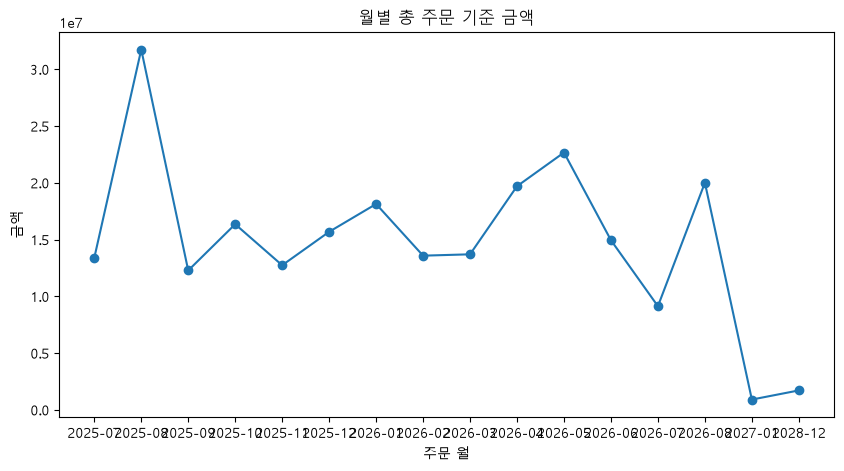

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 총 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")

In [18]:
products["price"].describe()

count       100.000000
mean     110040.000000
std       56433.910574
min        5000.000000
25%       65750.000000
50%      112000.000000
75%      161000.000000
max      200000.000000
Name: price, dtype: float64

히스토그램

Text(0, 0.5, '상품 수')

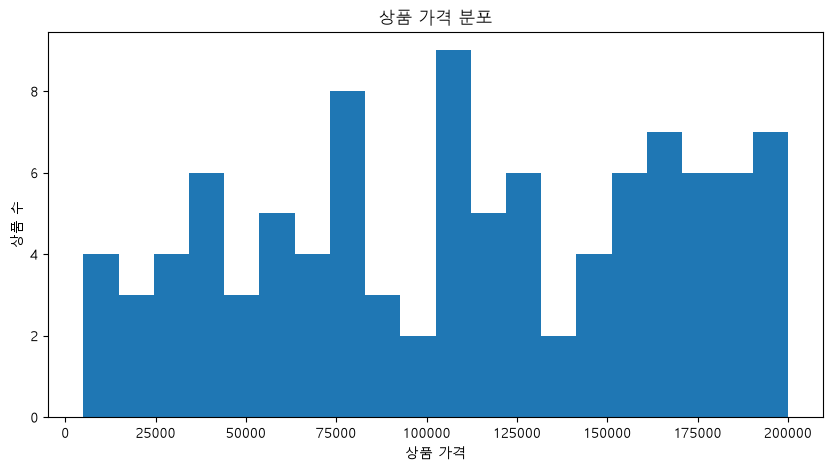

In [19]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    products["price"],
    bins=20,
)

ax.set_title("상품 가격 분포")
ax.set_xlabel("상품 가격")
ax.set_ylabel("상품 수")

In [25]:
age = df_visualization["age"].dropna()

Text(0, 0.5, '고객 수')

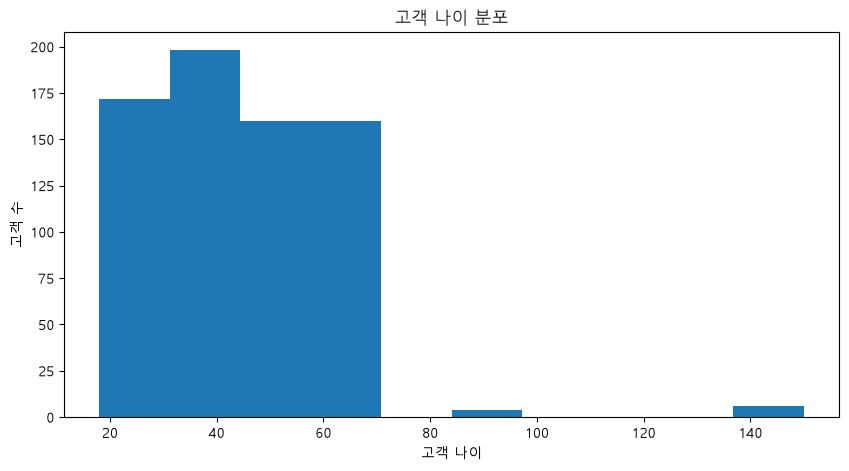

In [27]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    age,
    bins=10,
)

ax.set_title("고객 나이 분포")
ax.set_xlabel("고객 나이")
ax.set_ylabel("고객 수")

In [24]:
product_quantity = df_visualization.groupby("product_id", as_index=False).agg(
    total_qauntity = ("quantity", "sum")
)
product_quantity

,product_id,total_qauntity
0,1,20.0
1,2,19.0
2,3,7.0
3,4,23.0
4,5,24.0
...,...,...
91,96,75.0
92,97,31.0
93,98,25.0
94,99,18.0


In [28]:
product_sales = (
    df_visualization
    .groupby("product_id", as_index=False)
    .agg(
        total_amount=("line_total", "sum"),
        total_quantity=("quantity", "sum"),
    )
)

product_sales

,product_id,total_amount,total_quantity
0,1,1220000.0,20.0
1,2,2926000.0,19.0
2,3,336000.0,7.0
3,4,759000.0,23.0
4,5,1752000.0,24.0
...,...,...,...
91,96,7200000.0,75.0
92,97,5797000.0,31.0
93,98,800000.0,25.0
94,99,3366000.0,18.0


Text(0, 0.5, '총 판매 수량')

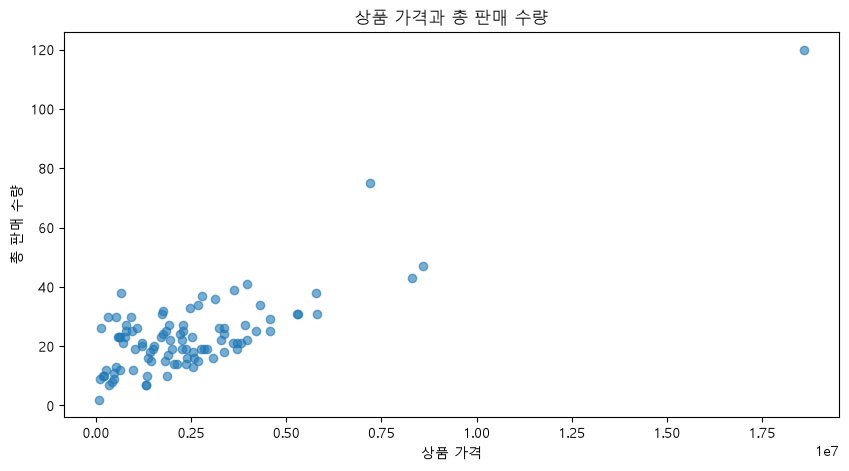

In [39]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    product_sales["total_amount"],
    product_sales["total_quantity"],
    alpha=0.6,
)

ax.set_title("상품 가격과 총 판매 수량")
ax.set_xlabel("상품 가격")
ax.set_ylabel("총 판매 수량")

In [33]:
customer_sales = df_visualization.groupby("customer_id", dropna=False, as_index=False).agg(
    total_amount=("line_total", "sum"),
    order_count = ("order_id", "nunique")
).sort_values("total_amount", ascending=False)

customer_sales

,customer_id,total_amount,order_count
15,18.0,16666000.0,2
2,3.0,8909000.0,7
17,20.0,6200000.0,6
45,52.0,5388000.0,5
11,14.0,5122000.0,4
...,...,...,...
105,131.0,176000.0,1
58,72.0,160000.0,1
70,86.0,128000.0,1
103,129.0,88000.0,1


In [36]:
top_customers = customer_sales.head(10).reset_index(drop=True)
top_customers

,customer_id,total_amount,order_count
0,18.0,16666000.0,2
1,3.0,8909000.0,7
2,20.0,6200000.0,6
3,52.0,5388000.0,5
4,14.0,5122000.0,4
5,55.0,4850000.0,6
6,90.0,4847000.0,5
7,22.0,4667000.0,4
8,15.0,4281000.0,5
9,115.0,3988000.0,4


<BarContainer object of 10 artists>

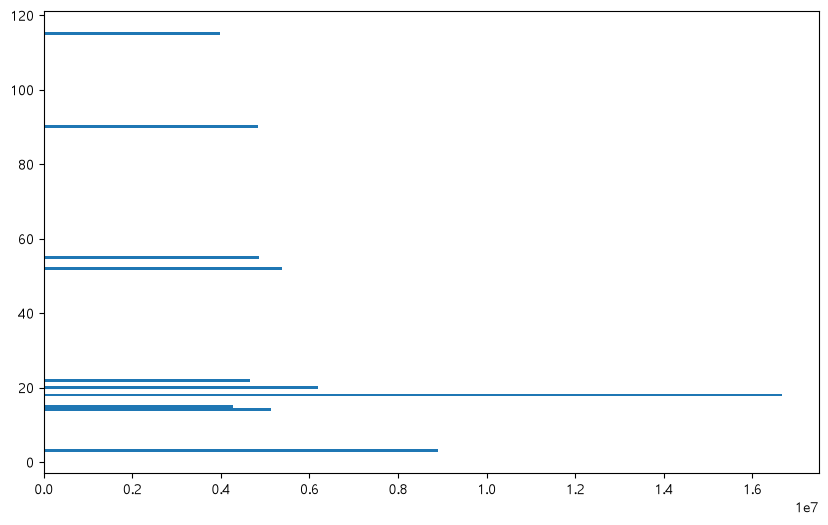

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)

<BarContainer object of 10 artists>

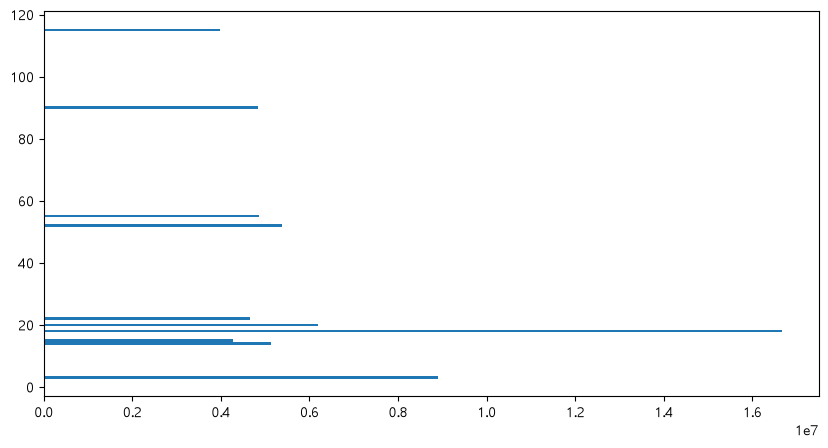

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    top_customers["customer_id"],
    top_customers["total_amount"],
)

ax.set_title("재")
ax.set_xlabel("상품 가격")
ax.set_ylabel("총 판매 수량")



fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)